In [1]:
import pandas as pd 
df = pd.read_excel("patients.xlsx")

In [2]:
df['Date_of_Admission'] = pd.to_datetime(df['Date_of_Admission'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])

df['Length_of_Stay'] = (df['Discharge_Date'] - df['Date_of_Admission']).dt.days

In [3]:
df.groupby('Medical_Condition')['Billing_Amount'].mean().sort_values(ascending=False)

Medical_Condition
Obesity         25785.645114
Asthma          25682.434608
Diabetes        25652.317155
Hypertension    25496.392338
Arthritis       25487.287597
Cancer          25230.966133
Name: Billing_Amount, dtype: float64

In [4]:
df[['Age', 'Billing_Amount', 'Length_of_Stay']].corr()

,Age,Billing_Amount,Length_of_Stay
Age,1.000000,-0.000981,0.007899
Billing_Amount,-0.000981,1.000000,-0.004570
Length_of_Stay,0.007899,-0.004570,1.000000


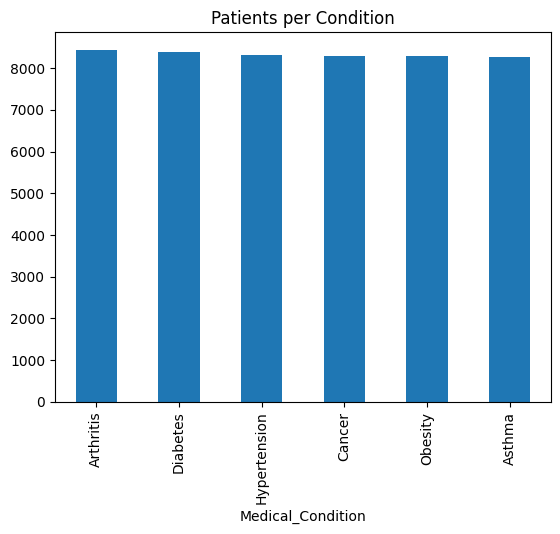

In [5]:
import matplotlib.pyplot as plt 

df['Medical_Condition'].value_counts().plot(kind='bar')
plt.title("Patients per Condition")
plt.show()

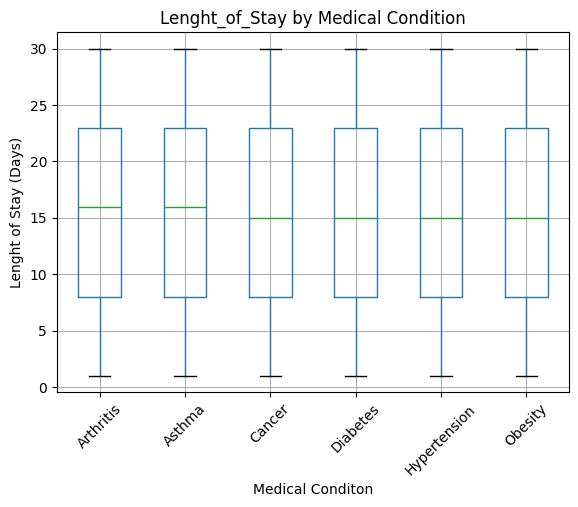

In [6]:
import matplotlib.pyplot as plt 

df.boxplot('Length_of_Stay', by='Medical_Condition')

plt.title('Lenght_of_Stay by Medical Condition')
plt.suptitle('') # removes extra automatic title 
plt.xlabel('Medical Conditon')
plt.ylabel('Lenght of Stay (Days)')
plt.xticks(rotation=45)

plt.show()

In [7]:
df['Date_of_Admission'] = pd.to_datetime(df['Date_of_Admission'])

In [8]:
monthly_admissions = df.groupby(
    df['Date_of_Admission'].dt.to_period('M')
).size()

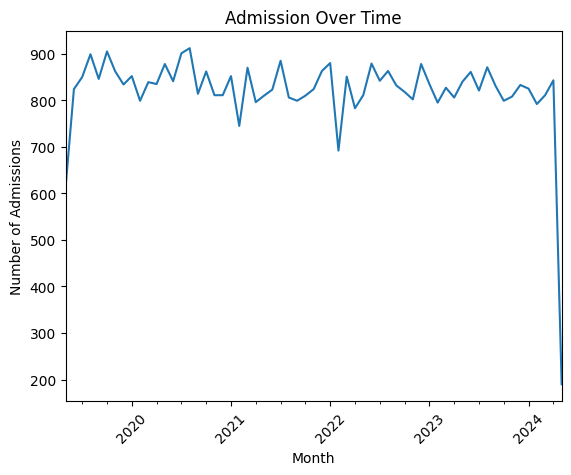

In [9]:
import matplotlib.pyplot as plt 

monthly_admissions.plot(kind='line')

plt.title('Admission Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)

plt.show()

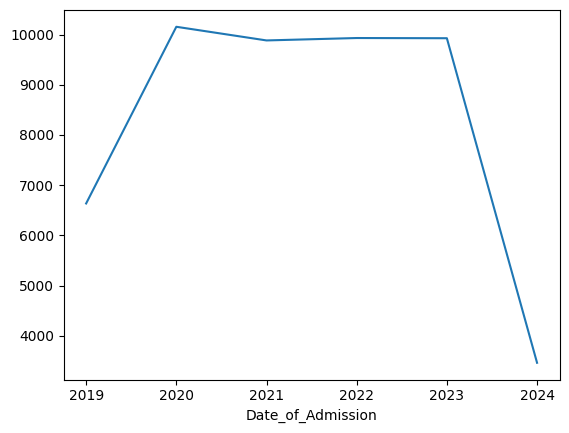

In [10]:
yearly = df.groupby(df['Date_of_Admission'].dt.year).size()
yearly.plot(kind='line')
plt.show()

In [11]:
df['Medical_Condition'] == 'Obesity'

0        False
1         True
2         True
3        False
4        False
         ...  
49987    False
49988    False
49989    False
49990    False
49991    False
Name: Medical_Condition, Length: 49992, dtype: bool

In [12]:
obesity_under_30 = df[
    (df['Medical_Condition'] == 'Obesity') &
    (df['Age'] < 30)
]

obesity_under_30.head()

,Name,Age,Gender,Blood_Type,Medical_Condition,Date_of_Admission,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Length_of_Stay,Medication,Test_Results
43,Katherine Smith,26,Female,AB+,Obesity,2021-06-09,Mary Logan,"and Mcclure White Boone,",UnitedHealthcare,21784.445071,410,Urgent,2021-07-01,22,Paracetamol,Normal
53,Peggy Lee,24,Female,A-,Obesity,2022-04-08,Patrick Burns,"Nelson Walker Myers, and",UnitedHealthcare,6767.634397,180,Elective,2022-04-13,5,Lipitor,Abnormal
71,Jose Lopez,18,Male,A-,Obesity,2022-01-09,Erika Jackson,"Miles, and Weaver Hudson",Aetna,46956.545731,377,Emergency,2022-01-15,6,Aspirin,Inconclusive
120,Anne Howell,22,Female,A-,Obesity,2022-08-22,Patrick Carter,Cline-Carpenter,Blue Cross,23499.936251,178,Urgent,2022-09-07,16,Penicillin,Normal
199,Melissa Lawrence,20,Male,O+,Obesity,2023-07-09,John Hansen,"Humphrey and Browning Fitzgerald,",Blue Cross,35205.284598,104,Emergency,2023-07-15,6,Lipitor,Abnormal


In [13]:
import pandas as pd

df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 120],
    labels=['<30', '30-45', '45-60', '60+'],
    right=False
)

In [14]:
age_counts = df['Age Group'].value_counts().sort_index()
print(age_counts)

Age Group
<30       8700
30-45    11044
45-60    11172
60+      19076
Name: count, dtype: int64


In [15]:
obesity_df = df[df['Medical_Condition'] == 'Obesity']

In [16]:
obesity_df['Age Group'] = pd.cut(
    obesity_df['Age'],
    bins=[0, 30, 45, 60, 120],
    labels=['<30', '30-45', '45-60', '60+'],
    right=False
)

In [17]:
df['Date_of_Admission'] = pd.to_datetime(df['Date_of_Admission'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])

df['length_of_stay'] = (
    df['Discharge_Date'] - df['Date_of_Admission']
).dt.days

In [18]:
long_stay = df[df['length_of_stay'] > 10]

In [19]:
long_stay['Age Group'] = pd.cut(
    long_stay['Age'],
    bins=[0, 30, 45, 60, 120],
    labels=['<30', '30-45', '45-60', '60+'],
    right=False
)

In [20]:
age_counts = long_stay['Age Group'].value_counts().sort_index()

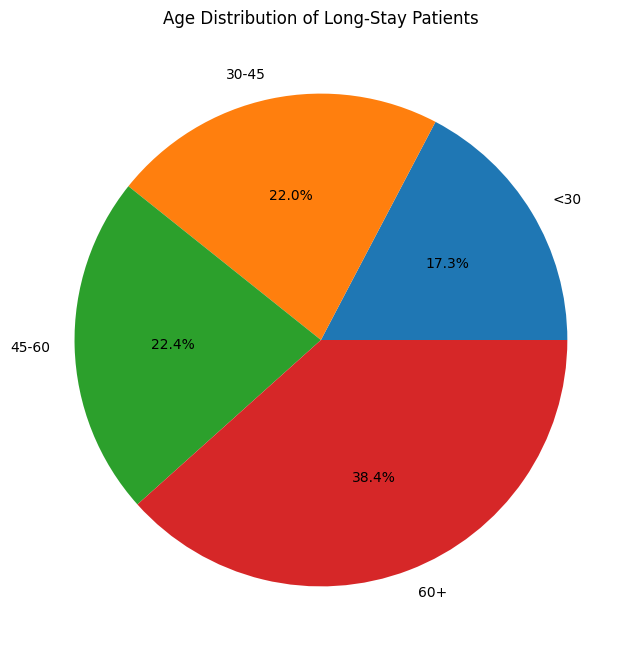

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title('Age Distribution of Long-Stay Patients')
plt.show()